[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/01_unidad/01_04_Imputacion_y_Calidad_Titanic.ipynb)


# Valores faltantes, outliers e imputación — Titanic (Seaborn)

Este notebook usa **`sns.load_dataset("titanic")`**: tabla con **891 filas** y **15 columnas** en la versión habitual de Seaborn, mezcla de variables **numéricas** y **categóricas**, y **faltantes reales** para practicar diagnóstico e **imputación** antes de modelado.

**Contenidos:**

1. Carga y primer inventario.
2. **Mecanismos de faltantes** (MCAR, MAR, MNAR) — marco conceptual.
3. **Detectar** `NaN` y contrastar con **códigos especiales** en otros datasets.
4. **Outliers** frente a faltantes: regla **IQR** y boxplots.
5. Partición **train/test** e **imputación** con `sklearn` (mediana, moda, **KNN** en numéricas).
6. Caso **alto porcentaje** de faltantes: columna `deck`.
7. **Codificación categórica:** `OneHotEncoder` en pipeline con la imputación.
8. Síntesis.

Ejecutar las celdas en orden (**Run All**) con `pandas`, `seaborn` y `scikit-learn` instalados.


## 1. Configuración e imports

- **`pandas` / `numpy`:** tablas y vectores.
- **`matplotlib` / `seaborn`:** gráficos exploratorios.
- **`sklearn.impute`:** `SimpleImputer`, `KNNImputer`.
- **`sklearn.model_selection`:** partición train/test.
- **`sklearn.compose` / `pipeline`:** estrategias por tipo de columna.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 20)

## 2. Carga de datos

La salida de la celda siguiente debe mostrar **shape (891, 15)** con la versión estándar de Seaborn y columnas en minúsculas (`age`, `embarked`, `deck`, etc.).


In [2]:
df = sns.load_dataset("titanic")
print("Shape:", df.shape)
df.head(8)

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False


## 3. Mecanismos de datos faltantes (idea general)

En la práctica casi nunca se demuestra con certeza el mecanismo, pero conviene **nombrar** tres esquemas habituales (Rubin):

- **MCAR (*missing completely at random*):** el hecho de que falte un valor **no** depende ni de otras columnas ni del valor no observado.
- **MAR (*missing at random*):** el faltante puede depender de **variables observadas** (por ejemplo, patrón de `age` según `pclass` o `sex`).
- **MNAR (*missing not at random*):** la probabilidad de faltar **sí** depende del valor no observado o de procesos no medidos; la imputación ingenua puede **sesgar** conclusiones.

La imputación (mediana, KNN, etc.) **no sustituye** el juicio de dominio; es una **convención** para poder entrenar modelos y cerrar el flujo de datos.


## 4. Identificar valores faltantes explícitos

En `pandas`, los faltantes aparecen como **`NaN`**. Se resumen con `df.isna().sum()` y el porcentaje sobre el total de filas.

Con el dataset estándar de Seaborn suele observarse:

- **`deck`:** del orden de **688** faltantes (**~77 %** de las filas) — proporción muy alta.
- **`age`:** del orden de **177** faltantes.
- **`embarked`** y **`embark_town`:** **2** faltantes cada uno (mismas filas, coherente entre columnas).

**Códigos especiales** (`?`, `-1`, `999`, cadenas vacías) en otros conjuntos deben convertirse a `NaN` antes de imputar. Aquí el problema ya viene como `NaN` en las columnas anteriores.


In [3]:
na_count = df.isna().sum().sort_values(ascending=False)
na_pct = (na_count / len(df) * 100).round(2)
pd.DataFrame({"n_missing": na_count, "pct": na_pct})[na_count > 0]

,n_missing,pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


El mapa de calor siguiente muestra un **subconjunto de filas**: cada columna es una variable; las casillas claras indican **valor ausente** (`NaN`) en esa fila y columna.


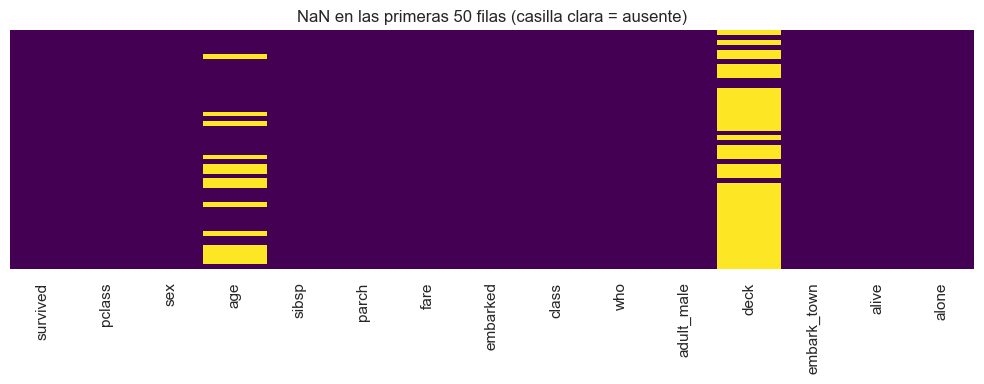

In [4]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna().iloc[:50], cbar=False, yticklabels=False, cmap="viridis")
plt.title("NaN en las primeras 50 filas (casilla clara = ausente)")
plt.tight_layout()
plt.show()

## 5. Outliers frente a valores faltantes

- **Faltante:** no hay información registrada (`NaN`).
- **Outlier:** valor **extremo pero observado**; puede ser error de medición o cola legítima de la distribución (p. ej. tarifas altas en `fare`).

Regla exploratoria **IQR**: $IQR = Q_3 - Q_1$, límites $[Q_1 - 1.5\,IQR,\; Q_3 + 1.5\,IQR]$. Los valores fuera del intervalo son **candidatos** a outlier, no errores demostrados.

En una ejecución sobre el conjunto completo suele obtenerse del orden de **11** candidatos en `age` y **116** en `fare` (regla IQR 1,5×; `fare` es muy asimétrico). Los límites y conteos exactos aparecen en la salida de la celda siguiente.


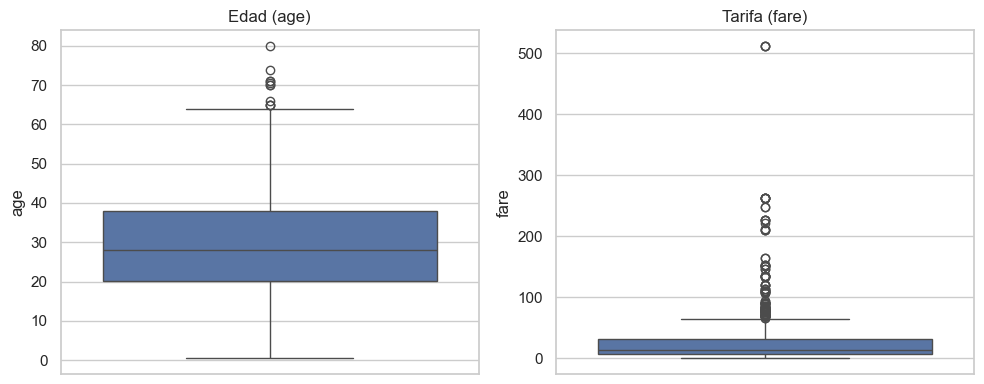

age: IQR límites [-6.69, 64.81] — candidatos outlier: 11 filas
fare: IQR límites [-26.72, 65.63] — candidatos outlier: 116 filas


In [5]:
def iqr_bounds(s: pd.Series, k=1.5):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return lo, hi

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, y="age", ax=axes[0])
axes[0].set_title("Edad (age)")
sns.boxplot(data=df, y="fare", ax=axes[1])
axes[1].set_title("Tarifa (fare)")
plt.tight_layout()
plt.show()

for col in ["age", "fare"]:
    lo, hi = iqr_bounds(df[col])
    out = ((df[col] < lo) | (df[col] > hi)) & df[col].notna()
    print(f"{col}: IQR límites [{lo:.2f}, {hi:.2f}] — candidatos outlier: {out.sum()} filas")


## 6. Partición train / test e imputación

Objetivo: **`survived`**. Predictores: **`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`**.

Con `test_size=0.25` y `random_state=42` estratificado por `survived`, la partición habitual es **668 filas en entrenamiento** y **223 en prueba**. En el conjunto de entrenamiento, con `random_state=42`, los faltantes en `age` son **131** (coincide con la salida impresa de la celda).

El **ajuste** (`fit`) de los imputadores debe hacerse **solo** sobre `X_train` para no filtrar información del test.


In [6]:
feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[feature_cols].copy()
y = df["survived"].copy()

num_cols = ["pclass", "age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Faltantes en age (train):", X_train["age"].isna().sum())
X_train.head()

Train: (668, 7) | Test: (223, 7)
Faltantes en age (train): 131


,pclass,sex,age,sibsp,parch,fare,embarked
486,1,female,35.0,1,0,90.000,S
238,2,male,19.0,0,0,10.500,S
722,2,male,34.0,0,0,13.000,S
184,3,female,4.0,0,2,22.025,S
56,2,female,21.0,0,0,10.500,S


## 7. `SimpleImputer`: mediana y moda

| Tipo | Estrategia | Comentario breve |
|------|------------|------------------|
| Numérica | `median` | más robusta que la media ante asimetría y outliers. |
| Numérica | `mean` | sensible a colas largas. |
| Categórica | `most_frequent` | moda; útil con pocos NaN (aquí `embarked`). |
| Categórica | `constant` | el ausente pasa a una categoría explícita. |

Tras `fit` en `X_train` y `transform` en train y test, la suma de `NaN` en las columnas transformadas debe ser **0**.


In [7]:
num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

preprocess.fit(X_train)
X_train_imp = preprocess.transform(X_train)
X_test_imp = preprocess.transform(X_test)

cols_out = num_cols + cat_cols
X_train_imp = pd.DataFrame(X_train_imp, columns=cols_out, index=X_train.index)
X_test_imp = pd.DataFrame(X_test_imp, columns=cols_out, index=X_test.index)

print("NaN restantes (train):", int(X_train_imp.isna().sum().sum()))
print("NaN restantes (test):", int(X_test_imp.isna().sum().sum()))
X_train_imp.head()

NaN restantes (train): 0
NaN restantes (test): 0


,pclass,age,sibsp,parch,fare,sex,embarked
486,1.0,35.0,1.0,0.0,90.0,female,S
238,2.0,19.0,0.0,0.0,10.5,male,S
722,2.0,34.0,0.0,0.0,13.0,male,S
184,3.0,4.0,0.0,2.0,22.025,female,S
56,2.0,21.0,0.0,0.0,10.5,female,S


### 7.1 KNNImputer en variables numéricas (con escalado)

`KNNImputer` rellena cada valor usando vecinos en el espacio de las variables numéricas. Como `fare` y `pclass` tienen escalas distintas, se aplica **`StandardScaler`** antes del KNN.

La gráfica compara la densidad de **`age`** observado (solo valores no nulos en train) con la columna `age` ya imputada en el array escalado: **no son directamente comparables en la misma escala** sin invertir el escalado; el propósito es **ilustrar** que el KNN devuelve valores en el espacio estandarizado.


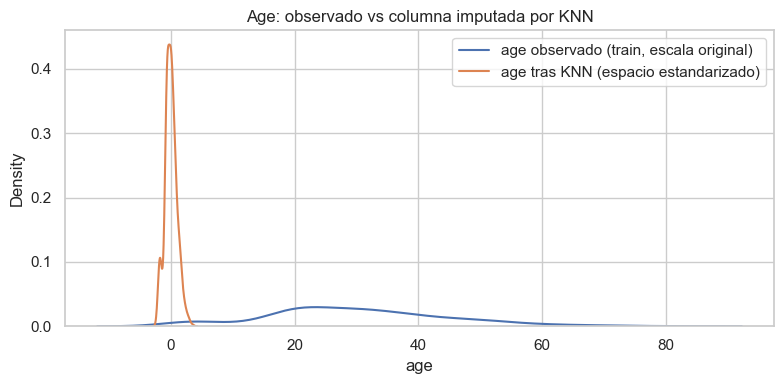

In [8]:
from sklearn.preprocessing import StandardScaler

num_train = X_train[num_cols].copy()
scaler = StandardScaler()
knn_imp = KNNImputer(n_neighbors=5, weights="distance")
num_scaled = scaler.fit_transform(num_train)
num_knn = knn_imp.fit_transform(num_scaled)

age_idx = num_cols.index("age")
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(X_train["age"].dropna(), label="age observado (train, escala original)", ax=ax)
sns.kdeplot(num_knn[:, age_idx], label="age tras KNN (espacio estandarizado)", ax=ax)
ax.set_title("Age: observado vs columna imputada por KNN")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Alto porcentaje de faltantes: `deck`

En el Titanic de Seaborn, **`deck`** tiene **688** valores ausentes sobre **891** filas (**≈77,2 %**). Imputar con la **moda** sin criterio de dominio suele ser **poco defendible**: alternativas habituales son crear la categoría **"Unknown"**, modelar el faltante como indicador aparte, o **excluir** `deck` del primer modelo.


In [9]:
deck_na = df["deck"].isna().sum()
print(f"NaN en deck: {deck_na} ({deck_na / len(df) * 100:.1f} %)")
display(df["deck"].value_counts(dropna=False))

NaN en deck: 688 (77.2 %)


deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

## 9. Codificación de categóricas: `OneHotEncoder`

Los modelos lineales y muchos otros algoritmos **no usan** directamente cadenas como `female` / `male` o los códigos de `embarked`: conviene expresar cada categoría como **columnas binarias** (1 si aplica, 0 si no). Eso es una codificación **one-hot**.

- **`OneHotEncoder`** aprende el conjunto de categorías en el **`fit`** (siempre sobre **train**) y genera la matriz dispersa o densa en **`transform`**.
- **`handle_unknown="ignore"`**: si en test apareciera una categoría **no vista** en train, no falla; esas columnas quedan en cero (útil en datos reales).
- Aquí se **encadena** dentro del mismo flujo por tipo: primero **`SimpleImputer`** en categóricas (para no tener `NaN` al codificar) y luego **`OneHotEncoder`**. Las numéricas siguen solo con imputación por mediana.

El resultado es una matriz **solo numérica**, lista para alimentar un clasificador en un `Pipeline` completo (eso se puede ver en una práctica posterior).


In [ ]:
from sklearn.preprocessing import OneHotEncoder

num_pipe_model = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
cat_pipe_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

model_preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe_model, num_cols),
        ("cat", cat_pipe_model, cat_cols),
    ]
)

model_preprocess.fit(X_train)
X_train_enc = model_preprocess.transform(X_train)
X_test_enc = model_preprocess.transform(X_test)

feat_names = model_preprocess.get_feature_names_out()
print("Shape train (tras imputación + one-hot):", X_train_enc.shape)
print("Shape test:", X_test_enc.shape)
print("Ejemplo de nombres de columnas generadas:", list(feat_names[:14]))

pd.DataFrame(X_train_enc, columns=feat_names, index=X_train.index).head()


## 10. Síntesis

- Inventariar faltantes con tablas y mapas; en este dataset destacan **`deck`** (~77 %), **`age`** (~177 filas) y **2** filas en `embarked`.
- Distinguir **outliers** (IQR, boxplots) de **NaN**; no confundir extremo observado con dato ausente.
- **Imputar** con `fit` solo en **train**; `SimpleImputer` con mediana + moda cubre un baseline sólido; **KNN** añade vecindad en features numéricas.
- Variables muy incompletas requieren decisión de **dominio**, no solo relleno automático.

